# Vehicle Manoeuvres and Driver Characteristics Analysis

#### Question: What proportion of vehicles were going ahead, turning, overtaking, or stationary at the time of collision and how do these manoeuvres vary by driver age and sex?

#### Introduction: This report examines patterns in vehicle manoeuvres using UK road casualty vehicle data. It focuses on how manoeuvre type varies by driver sex and age group. To improve clarity, manoeuvre categories were grouped, missing values were removed, and drivers aged 0 to 15 were excluded from the analysis. Tables and graphs are used to summarise the main findings.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://data.dft.gov.uk/road-accidents-safety-data/dft-road-casualty-statistics-vehicle-provisional-2025.csv"
collisions_data = pd.read_csv(url, low_memory = False)

collisions_data.head()



,collision_index,collision_year,collision_ref_no,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre_historic,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,...,age_of_driver,age_band_of_driver,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,driver_imd_decile,lsoa_of_driver,escooter_flag,driver_distance_banding
0,2025010551784,2025,010551784,3,9,0,18,19,7,3,...,55,8,-1,-1,-1,-1,4,E01002814,0,2
1,2025010551784,2025,010551784,2,9,0,18,19,3,7,...,36,7,-1,-1,-1,-1,6,E01000892,0,1
2,2025010551784,2025,010551784,1,9,0,18,19,7,3,...,53,8,-1,-1,-1,-1,-1,-1,0,-1
3,2025010551786,2025,010551786,1,3,0,-1,-1,9,9,...,30,6,-1,-1,-1,-1,3,E01004669,0,1
4,2025010551786,2025,010551786,2,9,0,6,6,9,9,...,49,8,-1,-1,-1,-1,5,E01015718,0,4


### Initial Data Inspection

The dataset contains information on vehicle manoeuvres, vehicle characteristics, driver characteristics,etc. Key variables include vehicle manoeuvre, driver age band, and driver sex. These variables are stored as numerical codes, with meanings provided in an accompanying lookup file. The data is recoded into descriptive categories to enable clearer analysis.

The meanings of coded variables were obtained from the official data guide:  
https://assets.publishing.service.gov.uk/media/691c6440e39a085bda43eed6/dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024.xlsx

In [29]:
# Keep only needed columns
collisions_data_TA = collisions_data[["vehicle_manoeuvre", "age_band_of_driver", "sex_of_driver"]].copy()	

# Recode vehicle_manoeuvre into manoeuvre_group
collisions_data_TA["manoeuvre_group"] = np.select(
    [
        collisions_data_TA["vehicle_manoeuvre"].isin([6, 7, 8, 9, 10]),
        collisions_data_TA["vehicle_manoeuvre"].isin([13, 14, 15]),
        collisions_data_TA["vehicle_manoeuvre"].isin([2, 3, 20]),
        collisions_data_TA["vehicle_manoeuvre"] == 19,
        collisions_data_TA["vehicle_manoeuvre"].isin([99, -1])
    ],
    [
        "Turning",
        "Overtaking",
        "Stationary",
        "Going ahead",
        "Missing"
    ],
    default="Other"
)

# Recode age_band_of_driver into age_of_driver
collisions_data_TA["age_of_driver"] = np.select(
    [
        collisions_data_TA["age_band_of_driver"] == 1,
        collisions_data_TA["age_band_of_driver"] == 2,
        collisions_data_TA["age_band_of_driver"] == 3,
        collisions_data_TA["age_band_of_driver"] == 4,
        collisions_data_TA["age_band_of_driver"] == 5,
        collisions_data_TA["age_band_of_driver"] == 6,
        collisions_data_TA["age_band_of_driver"] == 7,
        collisions_data_TA["age_band_of_driver"] == 8,
        collisions_data_TA["age_band_of_driver"] == 9,
        collisions_data_TA["age_band_of_driver"] == 10,
        collisions_data_TA["age_band_of_driver"] == 11,
        collisions_data_TA["age_band_of_driver"] == -1
    ],
    [
        "0-5",
        "6-10",
        "11-15",
        "16-20",
        "21-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66-75",
        "75+",
        "Missing"
    ],
    default="Other"
)

# Recode sex_of_driver into sex
collisions_data_TA["Sex"] = np.select(
    [
        collisions_data_TA["sex_of_driver"] == 1,
        collisions_data_TA["sex_of_driver"] == 2,
        collisions_data_TA["sex_of_driver"] == 3,
        collisions_data_TA["sex_of_driver"] == -1
    ],
    [
        "Male",
        "Female",
        "Missing",
        "Missing"
    ],
    default="Other"
)

In [19]:
# Clean data
collisions_data_TA_clean = collisions_data_TA[
    (collisions_data_TA["manoeuvre_group"] != "Missing") &
    (collisions_data_TA["age_of_driver"] != "Missing") &
    (collisions_data_TA["Sex"] != "Missing")
].copy()

# Removing age of drivers less than 16
collisions_data_TA_clean = collisions_data_TA_clean[~collisions_data_TA_clean["age_of_driver"].isin(["0-5", "6-10", "11-15"])].copy()

In [30]:
# Count manoeuvre_group and percentage
manoeuvre_counts = (
    collisions_data_TA_clean["manoeuvre_group"]
    .value_counts()
    .reset_index(name="n")
)
manoeuvre_counts["percent"] = manoeuvre_counts["n"] / manoeuvre_counts["n"].sum() * 100

manoeuvre_counts

,manoeuvre_group,n,percent
0,Going ahead,36873,56.806347
1,Turning,11100,17.100601
2,Other,9788,15.079341
3,Stationary,4627,7.128332
4,Overtaking,2522,3.885380


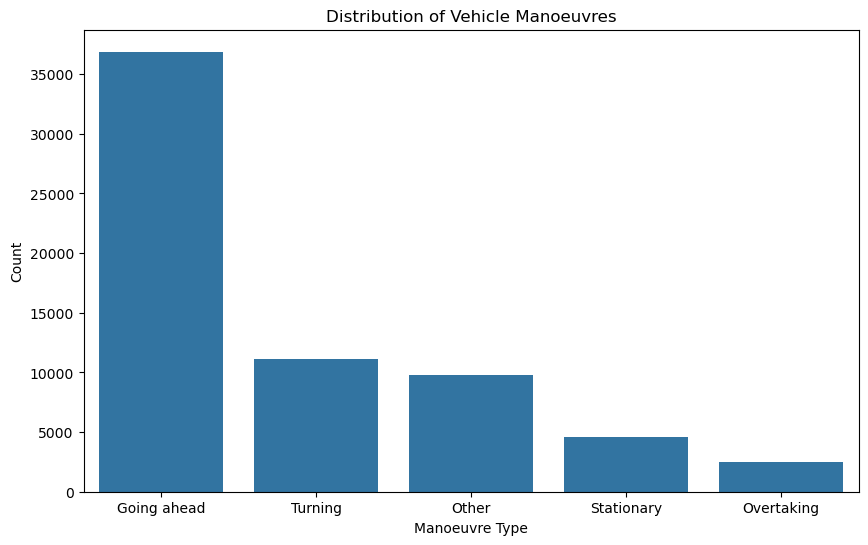

In [31]:
# Plot distribution of vehicle manoeuvres
plt.figure(figsize=(10, 6))
sns.barplot(data=manoeuvre_counts, x="manoeuvre_group", y="n")
plt.title("Distribution of Vehicle Manoeuvres")
plt.xlabel("Manoeuvre Type")
plt.ylabel("Count")
plt.show()

- The percentage distribution and the graph shows that more than half of all accidents (56.8%) occur when vehicles are going ahead.
- After that are acccidents while turning at 17.1%, followed by accidents while being stationary and ovetaking at 7.1% and 3.8% respectively.
- And alll the other manoeuvre account for the rest around 15% of accidents.
- Overall, the results indicate that the majority of incidents occur during routine forward movement rather than more complex driving actions.

In [32]:
# Count by manoeuvre_group and sex, with percentage within manoeuvre_group
sex_counts = (
    collisions_data_TA_clean.groupby(["manoeuvre_group", "Sex"])
    .size()
    .reset_index(name="n")
)

# get total per manoeuvre_group
sex_counts["total"] = sex_counts.groupby("manoeuvre_group")["n"].transform("sum")

# calculate percentage
sex_counts["percent"] = sex_counts["n"] / sex_counts["total"] * 100

sex_counts

,manoeuvre_group,Sex,n,total,percent
0,Going ahead,Female,10592,36873,28.725626
1,Going ahead,Male,26281,36873,71.274374
2,Other,Female,3165,9788,32.335513
3,Other,Male,6623,9788,67.664487
4,Overtaking,Female,425,2522,16.851705
5,Overtaking,Male,2097,2522,83.148295
6,Stationary,Female,1711,4627,36.978604
7,Stationary,Male,2916,4627,63.021396
8,Turning,Female,3891,11100,35.054054
9,Turning,Male,7209,11100,64.945946


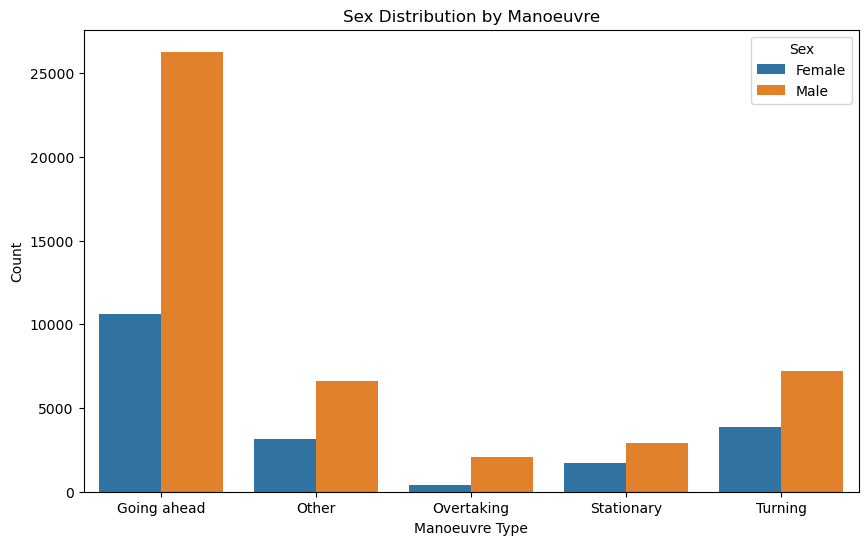

In [23]:
# Side-by-side bar plot: Sex distribution by manoeuvre
plt.figure(figsize=(10, 6))
sns.barplot(data=sex_counts, x="manoeuvre_group",y = "n", hue="Sex")
plt.title("Sex Distribution by Manoeuvre")
plt.xlabel("Manoeuvre Type")
plt.ylabel("Count")
plt.show()

- The distribution of manoeuvres by sex shows that male drivers account for the majority of acccidents across all manoeuvre types. This pattern is particularly pronounced for overtaking, where male drivers make up a substantially larger proportion of cases. 
- Although male drivers also dominate in other categories such as turning and stationary manoeuvres, the difference between male and female drivers is less pronounced in these cases. 
-Overall, the results indicate a consistent imbalance across all manoeuvre types, with male drivers more frequently represented in the dataset.

In [33]:
# Count by manoeuvre_group and age_of_driver
age_counts = (
    collisions_data_TA_clean.groupby(["manoeuvre_group", "age_of_driver"])
    .size()
    .reset_index(name="n")
)

# get total per manoeuvre_group
age_counts["total"] = age_counts.groupby("manoeuvre_group")["n"].transform("sum")

# calculate percentage
age_counts["percent"] = age_counts["n"] / age_counts["total"] * 100


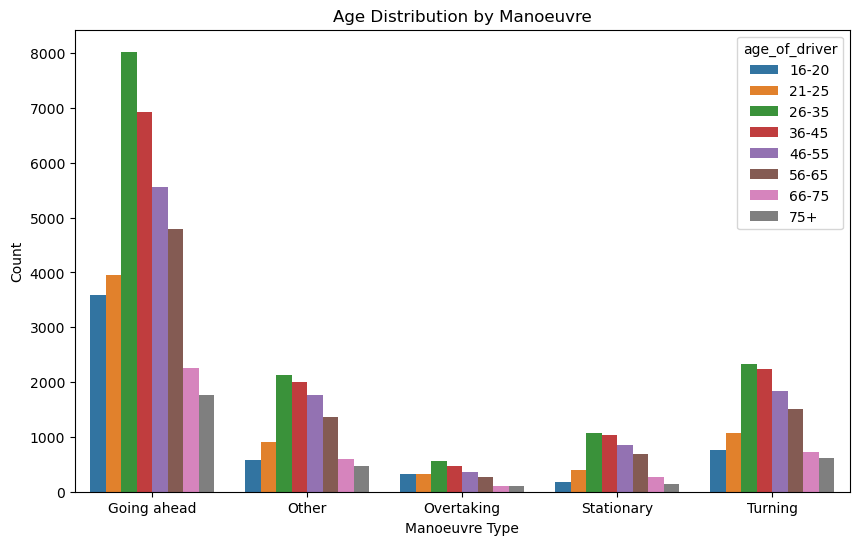

In [34]:
# Side-by-side bar plot: Age distribution by manoeuvre
plt.figure(figsize=(10, 6))
sns.barplot(data=age_counts, x="manoeuvre_group",y = "n", hue="age_of_driver")
plt.title("Age Distribution by Manoeuvre")
plt.xlabel("Manoeuvre Type")
plt.ylabel("Count")
plt.show()

- The distribution of manoeuvres across age groups shows that most observations are concentrated within the central age ranges, particularly among drivers aged between approximately 21 and 65. Younger and older age groups appear less frequently across all manoeuvre types. 
- While the overall pattern of manoeuvres is broadly similar across age groups, 26-35 aged drivers account for the majority of acccidents across all manoeuvre types.
- Overall, the results suggest that the majority of recorded incidents involve drivers within central age ranges, reflecting their higher presence on the road.

#### Conclusion

- In conclusion, the analysis shows that most incidents occur during routine forward movement rather than more complex manoeuvres.
- Male drivers are more frequently represented across all manoeuvre types, particularly in overtaking situations.
- Additionally, the majority of observations are concentrated among middle age groups, reflecting typical driving patterns. 
- Overall, the findings highlight clear differences in how manoeuvres are distributed across driver characteristics, providing useful insight into patterns within the dataset.
